In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn import metrics
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')

Maak een Jupyter Notebook waarin je het tabje “AmesHousing” van het bestand AmesHousing.xlsx inleest, als DataFrame in Python. Zorg ervoor dat elke Excel-kolom overeenkomt met een DataFrame-kolom.

In [2]:
dataset = pd.read_excel('AmesHousing.xlsx')
dataset

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,Mitchel,SLvl
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,Mitchel,1Story
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,Mitchel,SFoyer
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,Mitchel,1Story


Open AmesHousing.xlsx in Excel en lees de inhoud van het tabje “Data Dictionary” goed door. Deze geeft de betekenis weer van elke feature én van de targetvariabele. Zoek uit in welke kolom de targetvariabele staat en maak een top 3 van features waarvan je verwacht dat die het meest voorspellend zijn voor de targetvariabele. Let op: minstens één van deze features moet categorisch zijn! Noteer de gekozen features en het target in je logboek.

In [3]:
...

Ellipsis

Prepareer je data in je Jupyter Notebook:
    -One-hot encode je uitgekozen categorische feature(s)
    -Splits de dataset horizontaal én verticaal, zodat er vier “stukken” ontstaan.

In [4]:
dataset

,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,yes,6,1003,1003.0,7937,1984,1,3,Mitchel,SLvl
2926,2927,131000,yes,5,902,864.0,8885,1983,1,2,Mitchel,1Story
2927,2928,132000,no,5,970,912.0,10441,1992,1,3,Mitchel,SFoyer
2928,2929,170000,yes,5,1389,1389.0,10010,1974,1,2,Mitchel,1Story


In [5]:
Style = pd.get_dummies(dataset.loc[:, 'Garage'], drop_first=True)
Style = Style.rename(columns= {'yes' : 'Garage'})
Style

,Garage
0,True
1,True
2,True
3,True
4,True
...,...
2925,True
2926,True
2927,False
2928,True


In [6]:
dataset = dataset.drop(['Garage'], axis=1)
dataset = pd.concat([dataset, Style], axis=1)
dataset

,ID,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style,Garage
0,1,215000,6,1656,1080.0,31770,1960,1,3,NAmes,1Story,True
1,2,105000,5,896,882.0,11622,1961,1,2,NAmes,1Story,True
2,3,172000,6,1329,1329.0,14267,1958,1,3,NAmes,1Story,True
3,4,244000,7,2110,2110.0,11160,1968,2,3,NAmes,1Story,True
4,5,189900,5,1629,928.0,13830,1997,2,3,Gilbert,2Story,True
...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,142500,6,1003,1003.0,7937,1984,1,3,Mitchel,SLvl,True
2926,2927,131000,5,902,864.0,8885,1983,1,2,Mitchel,1Story,True
2927,2928,132000,5,970,912.0,10441,1992,1,3,Mitchel,SFoyer,False
2928,2929,170000,5,1389,1389.0,10010,1974,1,2,Mitchel,1Story,True


In [7]:
df_2d = dataset.loc[:, ['Garage', 'Overall Qual', 'Year Built']]

In [8]:
aantal_clusters = 4
KMean = KMeans(n_clusters=aantal_clusters, random_state=42)
Kmean= KMean.fit_predict(df_2d[['Garage', 'Overall Qual', 'Year Built']])
Kmean

array([1, 1, 1, ..., 0, 3, 0], shape=(2930,), dtype=int32)

In [9]:
kmeans_centre = pd.DataFrame(KMean.cluster_centers_, columns=['Garage', 'Overall Qual', 'Year Built'])
kmeans_centre.index
kmeans_centre

,Garage,Overall Qual,Year Built
0,0.985965,7.257895,2001.676316
1,0.933635,5.082956,1951.787330
2,0.838554,5.293976,1917.069880
3,0.956461,5.641854,1972.674157


In [10]:
afstanden_tot_centre = pd.DataFrame(euclidean_distances (df_2d, kmeans_centre), index = df_2d.index) 
afstanden_tot_centre

,0,1,2,3
0,41.695297,8.263977,42.936229,12.679291
1,40.738937,9.213282,43.931401,11.691870
2,43.694428,6.280337,40.936528,14.678592
3,33.677306,16.325750,50.958942,4.867669
4,5.192900,45.212794,79.930824,24.334348
...,...,...,...,...
2925,17.721022,32.225789,66.934039,11.331588
2926,18.812311,31.212850,65.930974,10.345864
2927,9.985054,40.223592,74.935389,19.360139
2928,27.768269,22.212924,56.931108,1.473679


In [11]:
for cluster_nummer in range(aantal_clusters):
    afstanden_tot_centre = afstanden_tot_centre.rename(columns = {cluster_nummer: f'Afstand tot cluster_{cluster_nummer}'})
df_2d = pd.concat([df_2d, afstanden_tot_centre], axis = 1) 
df_2d

,Garage,Overall Qual,Year Built,Afstand tot cluster_0,Afstand tot cluster_1,Afstand tot cluster_2,Afstand tot cluster_3
0,True,6,1960,41.695297,8.263977,42.936229,12.679291
1,True,5,1961,40.738937,9.213282,43.931401,11.691870
2,True,6,1958,43.694428,6.280337,40.936528,14.678592
3,True,7,1968,33.677306,16.325750,50.958942,4.867669
4,True,5,1997,5.192900,45.212794,79.930824,24.334348
...,...,...,...,...,...,...,...
2925,True,6,1984,17.721022,32.225789,66.934039,11.331588
2926,True,5,1983,18.812311,31.212850,65.930974,10.345864
2927,False,5,1992,9.985054,40.223592,74.935389,19.360139
2928,True,5,1974,27.768269,22.212924,56.931108,1.473679


In [12]:

df_2d['Cluster'] = df_2d.iloc[:, -3:].idxmin(axis = 1)
df_2d = df_2d.replace('Afstand tot cluster_0', 'Cluster 0') 
df_2d = df_2d.replace('Afstand tot cluster_1', 'Cluster 1') 
df_2d = df_2d.replace('Afstand tot cluster_2', 'Cluster 2') 
df_2d = df_2d.replace('Afstand tot cluster_3', 'Cluster 3') 
df_2d

,Garage,Overall Qual,Year Built,Afstand tot cluster_0,Afstand tot cluster_1,Afstand tot cluster_2,Afstand tot cluster_3,Cluster
0,True,6,1960,41.695297,8.263977,42.936229,12.679291,Cluster 1
1,True,5,1961,40.738937,9.213282,43.931401,11.691870,Cluster 1
2,True,6,1958,43.694428,6.280337,40.936528,14.678592,Cluster 1
3,True,7,1968,33.677306,16.325750,50.958942,4.867669,Cluster 3
4,True,5,1997,5.192900,45.212794,79.930824,24.334348,Cluster 3
...,...,...,...,...,...,...,...,...
2925,True,6,1984,17.721022,32.225789,66.934039,11.331588,Cluster 3
2926,True,5,1983,18.812311,31.212850,65.930974,10.345864,Cluster 3
2927,False,5,1992,9.985054,40.223592,74.935389,19.360139,Cluster 3
2928,True,5,1974,27.768269,22.212924,56.931108,1.473679,Cluster 3


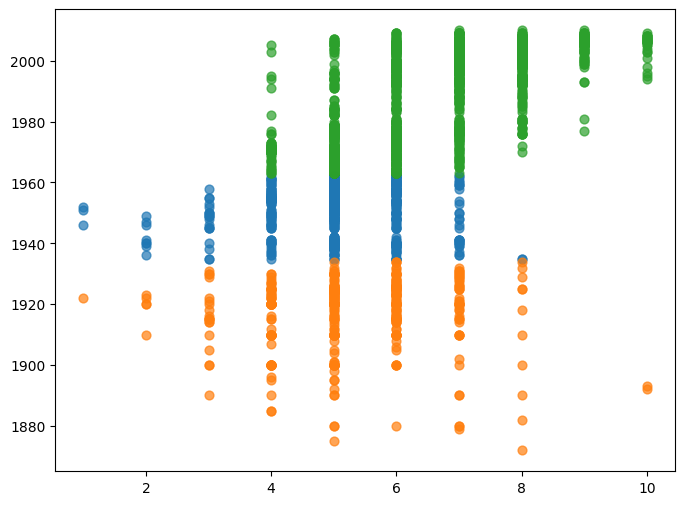

In [13]:
plt.figure(figsize=(8, 6))
for cluster_id, group in df_2d.groupby('Cluster'):
    plt.scatter( group['Overall Qual'], 
    group['Year Built'], 
    label=f'{cluster_id}',
    alpha=0.7,
    s=40)

INTERCLUSTERAFSTANDEN
               Cluster 0      Cluster 1      Cluster 2      Cluster 3  \
Cluster 0       0.000000  162933.363105   94965.552075   49465.773941   
Cluster 1  162933.363105       0.000000  257898.910599  212399.133174   
Cluster 2   94965.552075  257898.910599       0.000000   45499.778326   
Cluster 3   49465.773941  212399.133174   45499.778326       0.000000   
Cluster 4   66049.961547   96883.401562  161015.510770  115515.732705   
Cluster 5  327967.210313  165033.847418  422932.755683  377432.979142   

               Cluster 4      Cluster 5  
Cluster 0   66049.961547  327967.210313  
Cluster 1   96883.401562  165033.847418  
Cluster 2  161015.510770  422932.755683  
Cluster 3  115515.732705  377432.979142  
Cluster 4       0.000000  261917.248847  
Cluster 5  261917.248847       0.000000  
INTRACLUSTERAFSTANDEN VOLGENS DE ELLEBOOGMETHODE


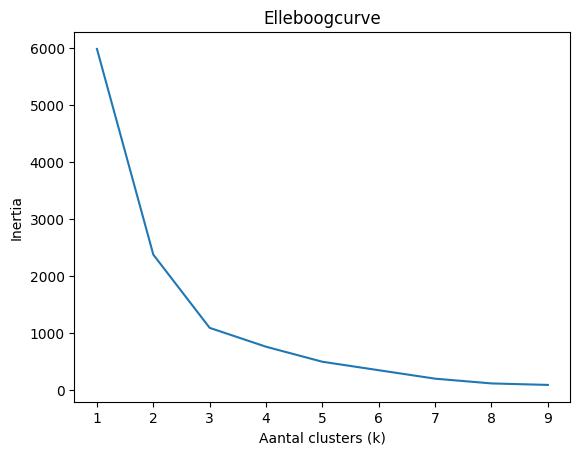

In [18]:

df = dataset.loc[:, ['SalePrice', 'Overall Qual', 'Year Built', 'Garage']]
aantal_clusters = 6
kmeans = KMeans (n_clusters = aantal_clusters, random_state = 42)
kmeans.fit_predict(df)
kmeans_centra = pd.DataFrame(kmeans.cluster_centers_, columns = df.columns)
kmeans_centra.index.name = 'Cluster'
afstanden_tot_centra = pd.DataFrame (euclidean_distances (df, kmeans_centra), index = df.index)
for cluster_nummer in range(aantal_clusters):
    afstanden_tot_centra = afstanden_tot_centre.rename(columns = {cluster_nummer: f'Afstand tot cluster_{cluster_nummer}'})
df = pd.concat([df, afstanden_tot_centra], axis= 1)

df['Cluster'] = df.iloc[:, -6:].idxmin(axis = 1)
df = df.replace('Afstand tot cluster_0', 'Cluster 0') 
df = df.replace('Afstand tot cluster_1', 'Cluster 1') 
df = df.replace('Afstand tot cluster_2', 'Cluster 2')
df = df.replace('Afstand tot cluster_3', 'Cluster 3')
intercluster_matrix = pd.DataFrame(
    euclidean_distances (kmeans_centra, kmeans_centra), 
    index=[f'Cluster {i}' for i in kmeans_centra.index], 
    columns=[f'Cluster {i}' for i in kmeans_centra.index]
)

print("INTERCLUSTERAFSTANDEN") 
print(intercluster_matrix)
print("INTRACLUSTERAFSTANDEN VOLGENS DE ELLEBOOGMETHODE")
inertias = []
k_values = range(1, 10)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df[['Overall Qual', 'Garage']])
    inertias.append(kmeans. inertia_)
plt.plot(k_values, inertias)
plt.xlabel("Aantal clusters (k)")
plt.ylabel("Inertia")
plt.title("Elleboogcurve")
plt.show()